# FIFA World Cup Data Analytics
## SQL to Python Analytical Pipeline

This notebook connects Python directly to the FIFA_World_Cup_Analytics SQL Server database and performs the final analytical layer using Pandas, NumPy, Matplotlib, and Seaborn.

### Analytical Pipeline

SQL Server
→ Python
→ Pandas
→ EDA
→ Statistical Analysis
→ Visualization
→ Insights

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import scipy
import networkx as nx

print("Libraries imported successfully.")

Libraries imported successfully.


In [64]:
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [65]:
import pyodbc

SERVER = r"localhost\SQLEXPRESS02"
DATABASE = "FIFA_World_Cup_Analytics"
DRIVER = "ODBC Driver 18 for SQL Server"

connection_string = (
    f"DRIVER={{{DRIVER}}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

connection = pyodbc.connect(connection_string)

print("SQL Server connection successful.")

SQL Server connection successful.


In [66]:
test_query = """
SELECT
    DB_NAME() AS DatabaseName;
"""

test_df = pd.read_sql_query(test_query, connection)

test_df

C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1274689534.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql_query(test_query, connection)


,DatabaseName
0,FIFA_World_Cup_Analytics


In [67]:
matches_query = """
SELECT COUNT(*) AS TotalMatches
FROM dbo.Matches;
"""

df_matches = pd.read_sql_query(matches_query, connection)

df_matches

C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\3100657146.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_matches = pd.read_sql_query(matches_query, connection)


,TotalMatches
0,1352


In [68]:
record_check_query = """
SELECT SUM(TableRows) AS TotalRecords
FROM
(
    SELECT COUNT(*) AS TableRows FROM dbo.Confederations
    UNION ALL
    SELECT COUNT(*) FROM dbo.Federations
    UNION ALL
    SELECT COUNT(*) FROM dbo.Teams
    UNION ALL
    SELECT COUNT(*) FROM dbo.Players
    UNION ALL
    SELECT COUNT(*) FROM dbo.Tournaments
    UNION ALL
    SELECT COUNT(*) FROM dbo.Stadiums
    UNION ALL
    SELECT COUNT(*) FROM dbo.Matches
    UNION ALL
    SELECT COUNT(*) FROM dbo.Team_Appearances
    UNION ALL
    SELECT COUNT(*) FROM dbo.Player_Appearances
    UNION ALL
    SELECT COUNT(*) FROM dbo.Goals
    UNION ALL
    SELECT COUNT(*) FROM dbo.Bookings
    UNION ALL
    SELECT COUNT(*) FROM dbo.Substitutions
    UNION ALL
    SELECT COUNT(*) FROM dbo.Match_Attendance
    UNION ALL
    SELECT COUNT(*) FROM dbo.Player_Match_Stats
    UNION ALL
    SELECT COUNT(*) FROM dbo.Team_Match_Stats
    UNION ALL
    SELECT COUNT(*) FROM dbo.Passing_Network_Edges
    UNION ALL
    SELECT COUNT(*) FROM dbo.FIFA_Rankings
) AS Counts;
"""

df_record_check = pd.read_sql_query(record_check_query, connection)

df_record_check

C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\3951645538.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_record_check = pd.read_sql_query(record_check_query, connection)


,TotalRecords
0,211808


In [69]:
def run_query(query):
    return pd.read_sql_query(query, connection)

print("SQL → Pandas helper is ready.")

SQL → Pandas helper is ready.


In [70]:
# ---------------------------------------------------------
# Generic analysis helpers
# ---------------------------------------------------------

def show_basic_info(df, name="DataFrame"):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nData types:")
    print(df.dtypes)
    print("\nPreview:")
    display(df.head())


def plot_horizontal_bar(
    df,
    category_col,
    value_col,
    title,
    top_n=10,
    figsize=(10, 6)
):
    plot_df = (
        df.nlargest(top_n, value_col)
          .sort_values(value_col, ascending=True)
    )

    plt.figure(figsize=figsize)
    plt.barh(
        plot_df[category_col],
        plot_df[value_col]
    )

    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel(category_col)
    plt.tight_layout()
    plt.show()


print("Analysis helpers are ready.")

Analysis helpers are ready.


In [71]:
# =========================================================
# Q6 — Top Men's World Cup Scorers
# =========================================================

q6_query = """
SELECT TOP 10
       p.PlayerID,
       LTRIM(RTRIM(p.DisplayName)) AS PlayerName,
       COUNT(g.GoalID) AS TotalGoals
FROM dbo.Goals AS g
INNER JOIN dbo.Players AS p
        ON g.PlayerID = p.PlayerID
INNER JOIN dbo.Matches AS m
        ON g.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND ISNULL(g.OwnGoal, 0) = 0
GROUP BY
       p.PlayerID,
       p.DisplayName
ORDER BY
       TotalGoals DESC,
       PlayerName;
"""

df_q6 = run_query(q6_query)

print("Q6 — Top Men's World Cup Scorers")
print("Shape:", df_q6.shape)

display(df_q6)

Q6 — Top Men's World Cup Scorers
Shape: (10, 3)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,PlayerID,PlayerName,TotalGoals
0,P-64077,Kylian Mbappé,22
1,P-14758,Lionel Messi,21
2,P-27787,Miroslav Klose,16
3,P-62722,Ronaldo,15
4,P-72441,Gerd Müller,14
5,P-58924,Harry Kane,14
6,P-77939,Just Fontaine,13
7,P-38906,Pelé,12
8,P-70442,Cristiano Ronaldo,11
9,P-91373,Jürgen Klinsmann,11


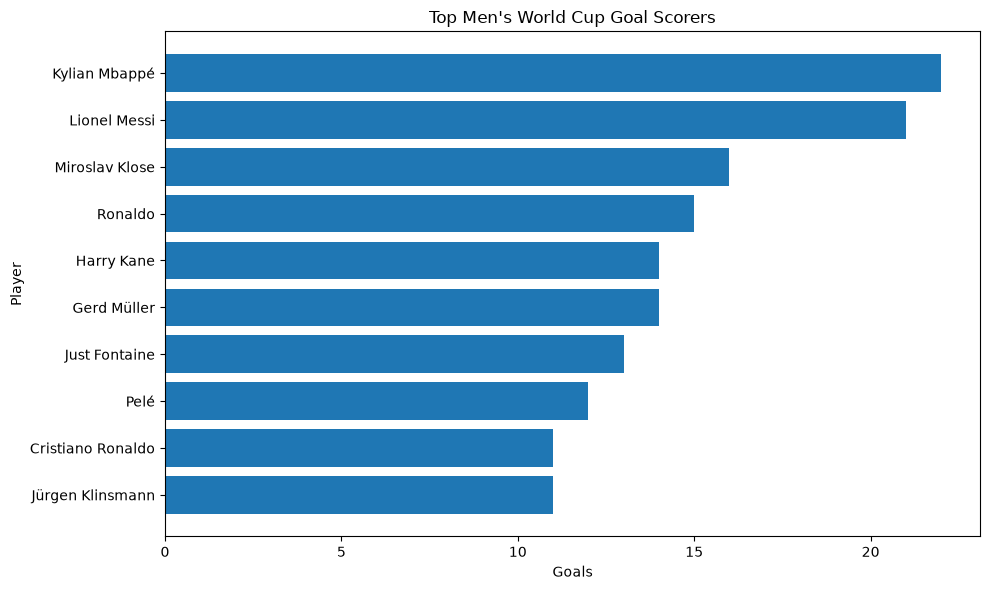

In [72]:
# Q6 — Visualization

plt.figure(figsize=(10, 6))

plot_df = df_q6.sort_values("TotalGoals", ascending=True)

plt.barh(
    plot_df["PlayerName"],
    plot_df["TotalGoals"]
)

plt.title("Top Men's World Cup Goal Scorers")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

In [73]:
# Q6 — Basic EDA

print("Maximum goals in Top 10:", df_q6["TotalGoals"].max())
print("Minimum goals in Top 10:", df_q6["TotalGoals"].min())
print("Mean goals among Top 10:", round(df_q6["TotalGoals"].mean(), 2))

display(
    df_q6[["PlayerName", "TotalGoals"]]
    .sort_values("TotalGoals", ascending=False)
)

Maximum goals in Top 10: 22
Minimum goals in Top 10: 11
Mean goals among Top 10: 14.9


,PlayerName,TotalGoals
0,Kylian Mbappé,22
1,Lionel Messi,21
2,Miroslav Klose,16
3,Ronaldo,15
4,Gerd Müller,14
5,Harry Kane,14
6,Just Fontaine,13
7,Pelé,12
8,Cristiano Ronaldo,11
9,Jürgen Klinsmann,11


In [74]:
# =========================================================
# Q9 — Most Active Men's World Cup Players
# =========================================================

q9_query = """
SELECT TOP 10
       p.PlayerID,
       LTRIM(RTRIM(p.DisplayName)) AS PlayerName,
       COUNT(pa.AppearanceID) AS MatchAppearances
FROM dbo.Player_Appearances AS pa
INNER JOIN dbo.Players AS p
        ON pa.PlayerID = p.PlayerID
INNER JOIN dbo.Matches AS m
        ON pa.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND pa.Appeared = 1
GROUP BY
       p.PlayerID,
       p.DisplayName
ORDER BY
       MatchAppearances DESC,
       PlayerName;
"""

df_q9 = run_query(q9_query)

print("Q9 — Most Active Men's World Cup Players")
print("Shape:", df_q9.shape)

display(df_q9)

Q9 — Most Active Men's World Cup Players
Shape: (10, 3)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,PlayerID,PlayerName,MatchAppearances
0,P-14758,Lionel Messi,34
1,P-70442,Cristiano Ronaldo,27
2,P-49502,Lothar Matthäus,25
3,P-27787,Miroslav Klose,24
4,P-29491,Luka Modrić,23
5,P-19408,Manuel Neuer,23
6,P-43222,Paolo Maldini,23
7,P-64077,Kylian Mbappé,22
8,P-80404,Diego Maradona,21
9,P-93884,Ivan Perišić,21


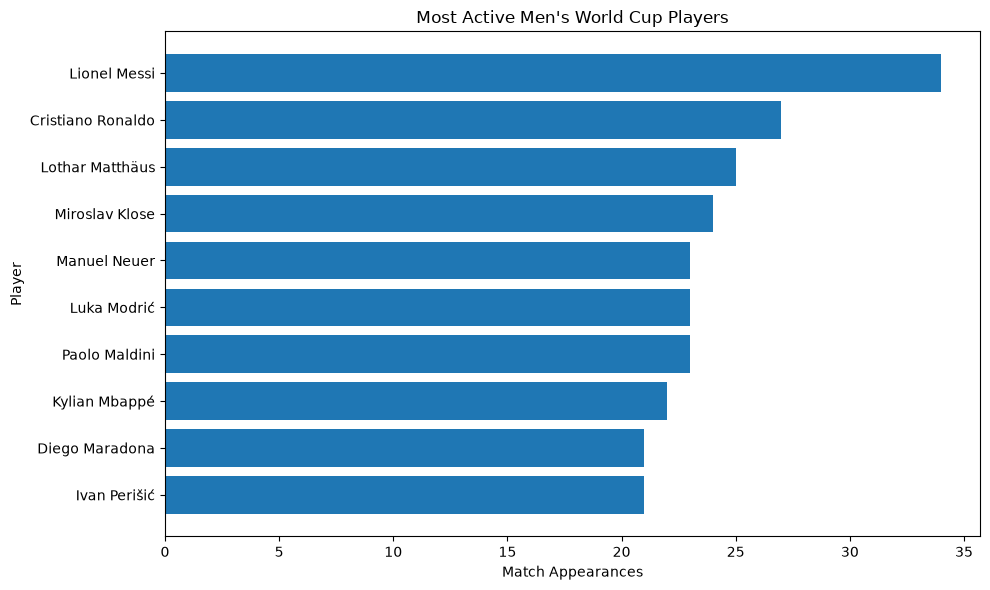

In [75]:
# Q9 — Visualization

plt.figure(figsize=(10, 6))

plot_df = df_q9.sort_values("MatchAppearances", ascending=True)

plt.barh(
    plot_df["PlayerName"],
    plot_df["MatchAppearances"]
)

plt.title("Most Active Men's World Cup Players")
plt.xlabel("Match Appearances")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

In [76]:
# Q9 — Basic EDA

print(
    "Maximum appearances in Top 10:",
    df_q9["MatchAppearances"].max()
)

print(
    "Minimum appearances in Top 10:",
    df_q9["MatchAppearances"].min()
)

print(
    "Mean appearances among Top 10:",
    round(df_q9["MatchAppearances"].mean(), 2)
)

display(
    df_q9[["PlayerName", "MatchAppearances"]]
    .sort_values("MatchAppearances", ascending=False)
)

Maximum appearances in Top 10: 34
Minimum appearances in Top 10: 21
Mean appearances among Top 10: 24.3


,PlayerName,MatchAppearances
0,Lionel Messi,34
1,Cristiano Ronaldo,27
2,Lothar Matthäus,25
3,Miroslav Klose,24
4,Luka Modrić,23
5,Manuel Neuer,23
6,Paolo Maldini,23
7,Kylian Mbappé,22
8,Diego Maradona,21
9,Ivan Perišić,21


In [77]:
# =========================================================
# Q12 — Inspect Passing Network Structure
# =========================================================

q12_structure_query = """
SELECT TOP 5 *
FROM dbo.Passing_Network_Edges;
"""

df_q12_structure = run_query(q12_structure_query)

print("Q12 — Passing Network sample")
print("Shape:", df_q12_structure.shape)

display(df_q12_structure)

Q12 — Passing Network sample
Shape: (5, 9)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,EdgeID,MatchID,TeamAppearanceID,TeamID,FromAppearanceID,ToAppearanceID,FromPlayerID,ToPlayerID,PassCount
0,2026-M001-MEX-RSA_MEX_01_01,S2-2026-M001-MEX-RSA,TA-S2-2026-M001-MEX-RSA_MEX,T-46,APP-S2-2026-M001-MEX-RSA_MEX_01,APP-S2-2026-M001-MEX-RSA_MEX_01,S2-MEX_raul_rangel,S2-MEX_raul_rangel,0
1,2026-M001-MEX-RSA_MEX_01_03,S2-2026-M001-MEX-RSA,TA-S2-2026-M001-MEX-RSA_MEX,T-46,APP-S2-2026-M001-MEX-RSA_MEX_01,APP-S2-2026-M001-MEX-RSA_MEX_03,S2-MEX_raul_rangel,P-36212,6
2,2026-M001-MEX-RSA_MEX_01_04,S2-2026-M001-MEX-RSA,TA-S2-2026-M001-MEX-RSA_MEX,T-46,APP-S2-2026-M001-MEX-RSA_MEX_01,APP-S2-2026-M001-MEX-RSA_MEX_04,S2-MEX_raul_rangel,P-26546,0
3,2026-M001-MEX-RSA_MEX_01_05,S2-2026-M001-MEX-RSA,TA-S2-2026-M001-MEX-RSA_MEX,T-46,APP-S2-2026-M001-MEX-RSA_MEX_01,APP-S2-2026-M001-MEX-RSA_MEX_05,S2-MEX_raul_rangel,P-09877,8
4,2026-M001-MEX-RSA_MEX_01_06,S2-2026-M001-MEX-RSA,TA-S2-2026-M001-MEX-RSA_MEX,T-46,APP-S2-2026-M001-MEX-RSA_MEX_01,APP-S2-2026-M001-MEX-RSA_MEX_06,S2-MEX_raul_rangel,S2-MEX_erik_lira,4


In [78]:
# =========================================================
# Q12 — Most Frequent Passing Connections
# =========================================================

q12_query = """
SELECT TOP 20
       pne.FromPlayerID,
       LTRIM(RTRIM(fp.DisplayName)) AS FromPlayerName,
       pne.ToPlayerID,
       LTRIM(RTRIM(tp.DisplayName)) AS ToPlayerName,
       SUM(pne.PassCount) AS TotalPasses
FROM dbo.Passing_Network_Edges AS pne
INNER JOIN dbo.Players AS fp
        ON pne.FromPlayerID = fp.PlayerID
INNER JOIN dbo.Players AS tp
        ON pne.ToPlayerID = tp.PlayerID
INNER JOIN dbo.Matches AS m
        ON pne.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND pne.PassCount > 0
GROUP BY
       pne.FromPlayerID,
       fp.DisplayName,
       pne.ToPlayerID,
       tp.DisplayName
ORDER BY
       TotalPasses DESC,
       pne.FromPlayerID,
       pne.ToPlayerID;
"""

df_q12 = run_query(q12_query)

df_q12["PassingConnection"] = (
    df_q12["FromPlayerName"]
    + " → "
    + df_q12["ToPlayerName"]
)

print("Q12 — Most Frequent Passing Connections")
print("Shape:", df_q12.shape)

display(
    df_q12[
        [
            "FromPlayerID",
            "FromPlayerName",
            "ToPlayerID",
            "ToPlayerName",
            "TotalPasses",
            "PassingConnection",
        ]
    ]
)

C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


Q12 — Most Frequent Passing Connections
Shape: (20, 6)


,FromPlayerID,FromPlayerName,ToPlayerID,ToPlayerName,TotalPasses,PassingConnection
0,P-99025,Aymeric Laporte,P-62341,Rodri,138,Aymeric Laporte → Rodri
1,S2-ESP_pau_cubarsi,Pau CUBARSI,P-62341,Rodri,132,Pau CUBARSI → Rodri
2,S2-ESP_pau_cubarsi,Pau CUBARSI,P-99025,Aymeric Laporte,123,Pau CUBARSI → Aymeric Laporte
3,P-99025,Aymeric Laporte,S2-ESP_pau_cubarsi,Pau CUBARSI,121,Aymeric Laporte → Pau CUBARSI
4,P-62341,Rodri,S2-ESP_pau_cubarsi,Pau CUBARSI,115,Rodri → Pau CUBARSI
5,P-62341,Rodri,P-99025,Aymeric Laporte,109,Rodri → Aymeric Laporte
6,S2-BRA_gabriel_magalhaes,GABRIEL MAGALHAES,P-76060,Marquinhos,107,GABRIEL MAGALHAES → Marquinhos
7,S2-NOR_sander_berge,Sander BERGE,S2-NOR_martin_odegaard,Martin ODEGAARD,100,Sander BERGE → Martin ODEGAARD
8,S2-ENG_ezri_konsa,Ezri KONSA,S2-ENG_marc_guehi,Marc GUEHI,98,Ezri KONSA → Marc GUEHI
9,P-56029,Virgil van Dijk,S2-NED_jan_paul_van_hecke,Jan Paul VAN HECKE,96,Virgil van Dijk → Jan Paul VAN HECKE


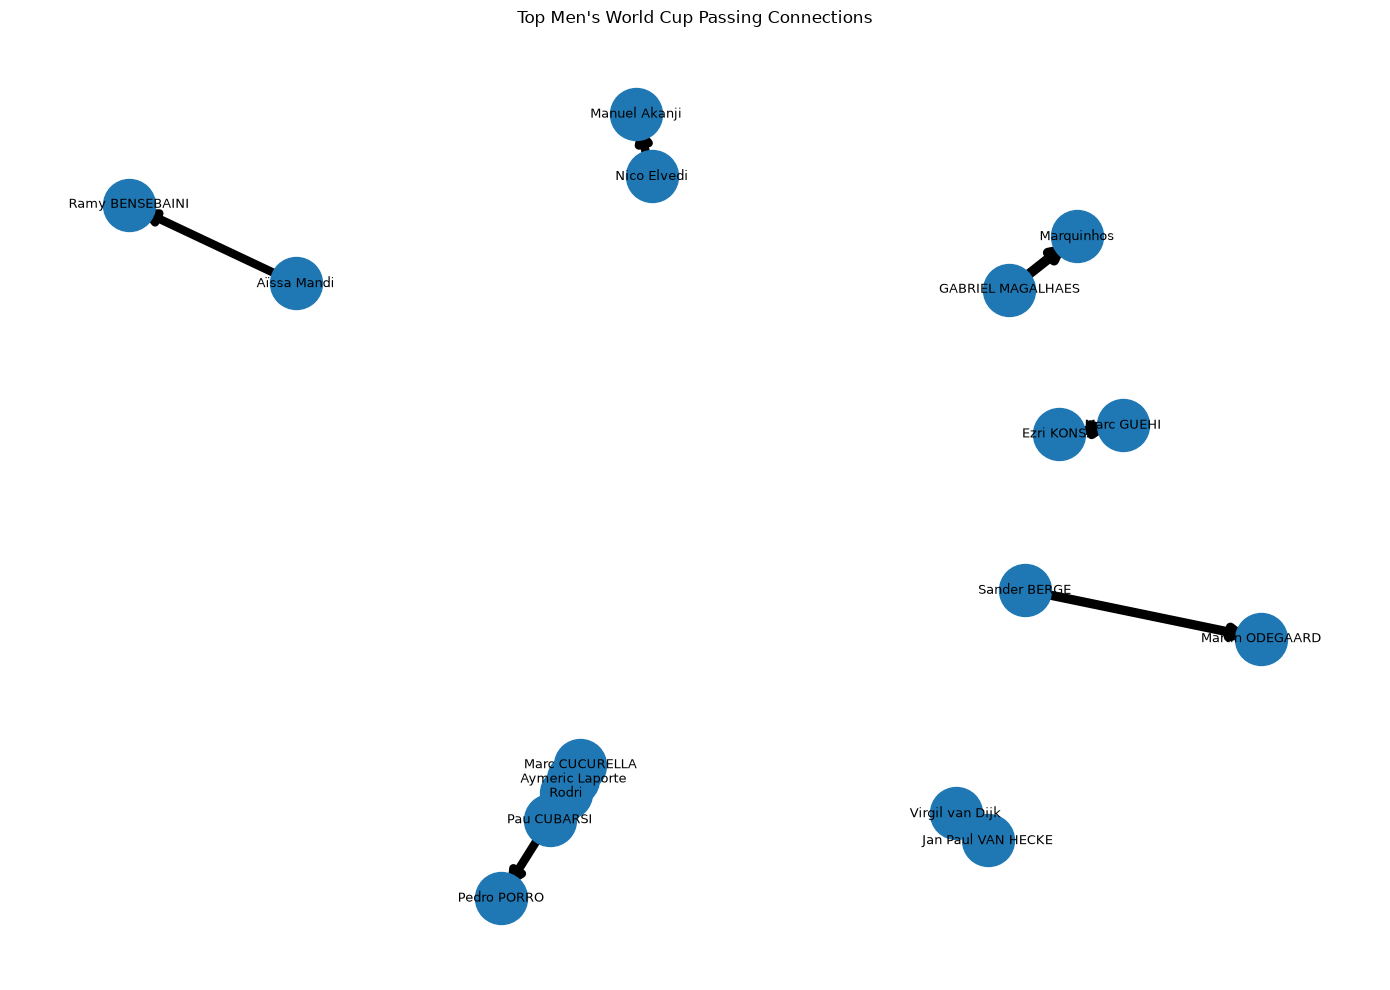

In [79]:
# =========================================================
# Q12 — Passing Network Visualization
# =========================================================

import networkx as nx

G = nx.DiGraph()

for _, row in df_q12.head(15).iterrows():
    G.add_edge(
        row["FromPlayerName"],
        row["ToPlayerName"],
        weight=row["TotalPasses"]
    )

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1400
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

edge_weights = [
    G[u][v]["weight"] / 15
    for u, v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_weights,
    arrows=True,
    arrowsize=18
)

plt.title("Top Men's World Cup Passing Connections")
plt.axis("off")
plt.tight_layout()
plt.show()

In [80]:
# =========================================================
# Q12 — Basic EDA
# =========================================================

print("Total passing connections returned:", len(df_q12))
print("Maximum total passes:", df_q12["TotalPasses"].max())
print("Minimum total passes:", df_q12["TotalPasses"].min())
print("Mean passes among Top 20:", round(df_q12["TotalPasses"].mean(), 2))

display(
    df_q12[
        ["PassingConnection", "TotalPasses"]
    ].sort_values(
        "TotalPasses",
        ascending=False
    )
)

Total passing connections returned: 20
Maximum total passes: 138
Minimum total passes: 79
Mean passes among Top 20: 100.75


,PassingConnection,TotalPasses
0,Aymeric Laporte → Rodri,138
1,Pau CUBARSI → Rodri,132
2,Pau CUBARSI → Aymeric Laporte,123
3,Aymeric Laporte → Pau CUBARSI,121
4,Rodri → Pau CUBARSI,115
5,Rodri → Aymeric Laporte,109
6,GABRIEL MAGALHAES → Marquinhos,107
7,Sander BERGE → Martin ODEGAARD,100
8,Ezri KONSA → Marc GUEHI,98
9,Virgil van Dijk → Jan Paul VAN HECKE,96


In [81]:
# =========================================================
# Q14 — Stadium Attendance vs Capacity
# =========================================================

q14_query = """
SELECT
    s.StadiumID,
    LTRIM(RTRIM(s.StadiumName)) AS StadiumName,
    s.StadiumCapacity,
    ma.Attendance,
    CAST(
        100.0 * ma.Attendance / NULLIF(s.StadiumCapacity, 0)
        AS DECIMAL(10,2)
    ) AS UtilizationPct
FROM dbo.Match_Attendance AS ma
INNER JOIN dbo.Matches AS m
        ON ma.MatchID = m.MatchID
INNER JOIN dbo.Stadiums AS s
        ON m.StadiumID = s.StadiumID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND ma.Attendance IS NOT NULL
  AND s.StadiumCapacity IS NOT NULL
  AND s.StadiumCapacity > 0
ORDER BY ma.Attendance DESC;
"""

df_q14 = run_query(q14_query)

print("Q14 — Stadium Attendance vs Capacity")
print("Shape:", df_q14.shape)

display(df_q14.head(20))

Q14 — Stadium Attendance vs Capacity
Shape: (964, 5)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,StadiumID,StadiumName,StadiumCapacity,Attendance,UtilizationPct
0,S-020,Estádio do Maracanã,200000,173850,86.93
1,S-020,Estádio do Maracanã,200000,152772,76.39
2,S-020,Estádio do Maracanã,200000,142429,71.21
3,S-020,Estádio do Maracanã,200000,138886,69.44
4,S-132,Estadio Azteca,115000,114600,99.65
5,S-132,Estadio Azteca,115000,114600,99.65
6,S-132,Estadio Azteca,115000,114580,99.63
7,S-132,Estadio Azteca,115000,114580,99.63
8,S-132,Estadio Azteca,115000,114500,99.57
9,S-132,Estadio Azteca,115000,110000,95.65


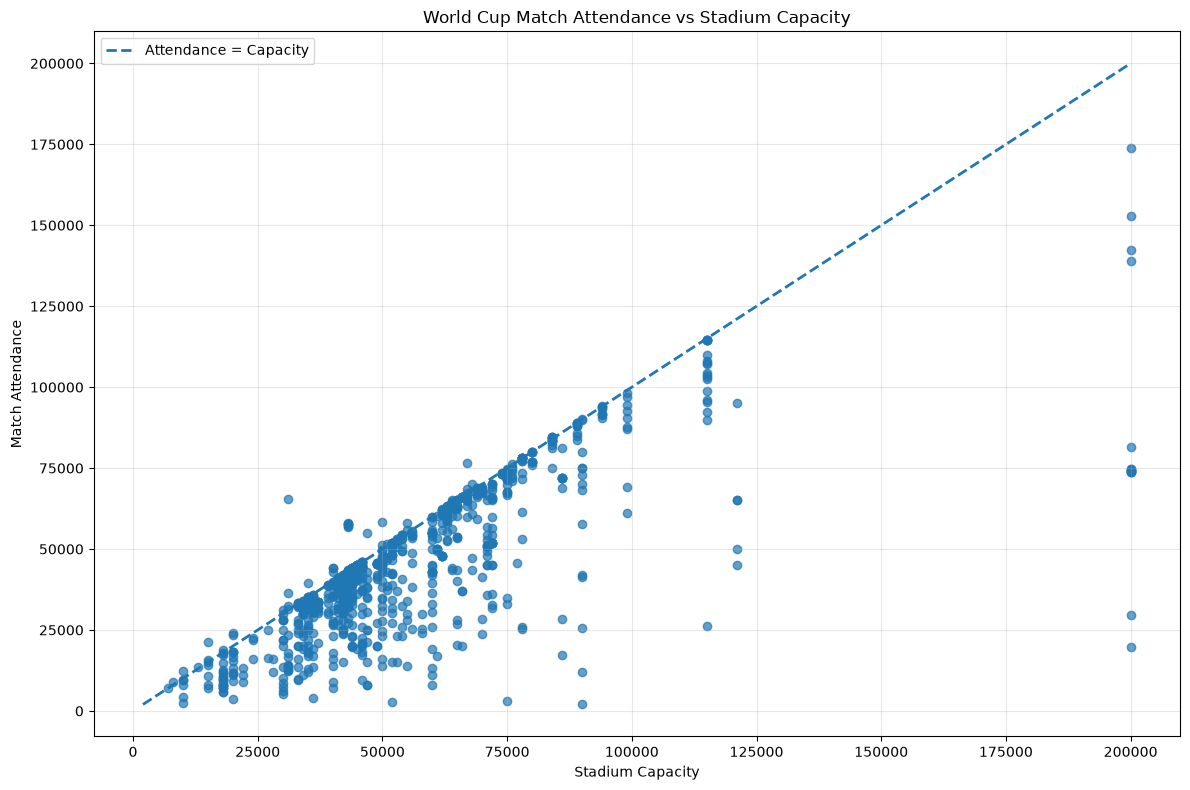

In [82]:
# =========================================================
# Q14 — Scatter Plot
# =========================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    df_q14["StadiumCapacity"],
    df_q14["Attendance"],
    alpha=0.7
)

min_value = min(
    df_q14["StadiumCapacity"].min(),
    df_q14["Attendance"].min()
)

max_value = max(
    df_q14["StadiumCapacity"].max(),
    df_q14["Attendance"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Attendance = Capacity"
)

plt.xlabel("Stadium Capacity")
plt.ylabel("Match Attendance")
plt.title("World Cup Match Attendance vs Stadium Capacity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
# =========================================================
# Q14 — Basic EDA
# =========================================================

print("Number of attendance records:", len(df_q14))
print("Maximum attendance:", df_q14["Attendance"].max())
print("Minimum attendance:", df_q14["Attendance"].min())
print("Average attendance:", round(df_q14["Attendance"].mean(), 2))

print(
    "Average stadium capacity:",
    round(df_q14["StadiumCapacity"].mean(), 2)
)

print(
    "Average utilization:",
    round(df_q14["UtilizationPct"].mean(), 2),
    "%"
)

print("\nTop 10 records by attendance:")

display(
    df_q14[
        [
            "StadiumName",
            "StadiumCapacity",
            "Attendance",
            "UtilizationPct"
        ]
    ].head(10)
)

print("\nRecords where attendance exceeds listed capacity:")

display(
    df_q14[
        df_q14["Attendance"] > df_q14["StadiumCapacity"]
    ][
        [
            "StadiumName",
            "StadiumCapacity",
            "Attendance",
            "UtilizationPct"
        ]
    ].head(10)
)

Number of attendance records: 964
Maximum attendance: 173850
Minimum attendance: 2000
Average attendance: 45577.52
Average stadium capacity: 55554.98
Average utilization: 82.82 %

Top 10 records by attendance:


,StadiumName,StadiumCapacity,Attendance,UtilizationPct
0,Estádio do Maracanã,200000,173850,86.93
1,Estádio do Maracanã,200000,152772,76.39
2,Estádio do Maracanã,200000,142429,71.21
3,Estádio do Maracanã,200000,138886,69.44
4,Estadio Azteca,115000,114600,99.65
5,Estadio Azteca,115000,114600,99.65
6,Estadio Azteca,115000,114580,99.63
7,Estadio Azteca,115000,114580,99.63
8,Estadio Azteca,115000,114500,99.57
9,Estadio Azteca,115000,110000,95.65



Records where attendance exceeds listed capacity:


,StadiumName,StadiumCapacity,Attendance,UtilizationPct
24,Rose Bowl,94000,94194,100.21
35,Estadio Santiago Bernabéu,90000,90089,100.10
49,Soccer City,84000,84490,100.58
50,Soccer City,84000,84490,100.58
51,Soccer City,84000,84455,100.54
52,Soccer City,84000,84377,100.45
53,Stanford Stadium,84000,84147,100.18
54,Soccer City,84000,84017,100.02
70,Olympiastadion,78000,78200,100.26
71,Luzhniki Stadium,78000,78011,100.01


In [84]:
# =========================================================
# Q17 — Average Goals per Match
# =========================================================

q17_query = """
SELECT
    t.TournamentID,
    YEAR(t.StartDate) AS TournamentYear,
    LTRIM(RTRIM(t.TournamentName)) AS TournamentName,
    COUNT(DISTINCT m.MatchID) AS TotalMatches,
    COUNT(g.GoalID) AS TotalGoals,
    CAST(
        1.0 * COUNT(g.GoalID) / NULLIF(COUNT(DISTINCT m.MatchID), 0)
        AS DECIMAL(10,4)
    ) AS AvgGoalsPerMatch
FROM dbo.Tournaments AS t
INNER JOIN dbo.Matches AS m
        ON t.TournamentID = m.TournamentID
LEFT JOIN dbo.Goals AS g
        ON m.MatchID = g.MatchID
WHERE t.Gender = 'Men'
GROUP BY
    t.TournamentID,
    YEAR(t.StartDate),
    t.TournamentName
ORDER BY TournamentYear;
"""

df_q17 = run_query(q17_query)

print("Q17 — Average Goals per Match")
print("Shape:", df_q17.shape)

display(df_q17)

Q17 — Average Goals per Match
Shape: (23, 6)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,TournamentID,TournamentYear,TournamentName,TotalMatches,TotalGoals,AvgGoalsPerMatch
0,WC-1930,1930,1930 FIFA Men's World Cup,18,70,3.8889
1,WC-1934,1934,1934 FIFA Men's World Cup,17,70,4.1176
2,WC-1938,1938,1938 FIFA Men's World Cup,18,84,4.6667
3,WC-1950,1950,1950 FIFA Men's World Cup,22,88,4.0000
4,WC-1954,1954,1954 FIFA Men's World Cup,26,140,5.3846
5,WC-1958,1958,1958 FIFA Men's World Cup,35,126,3.6000
6,WC-1962,1962,1962 FIFA Men's World Cup,32,89,2.7813
7,WC-1966,1966,1966 FIFA Men's World Cup,32,89,2.7813
8,WC-1970,1970,1970 FIFA Men's World Cup,32,95,2.9688
9,WC-1974,1974,1974 FIFA Men's World Cup,38,97,2.5526


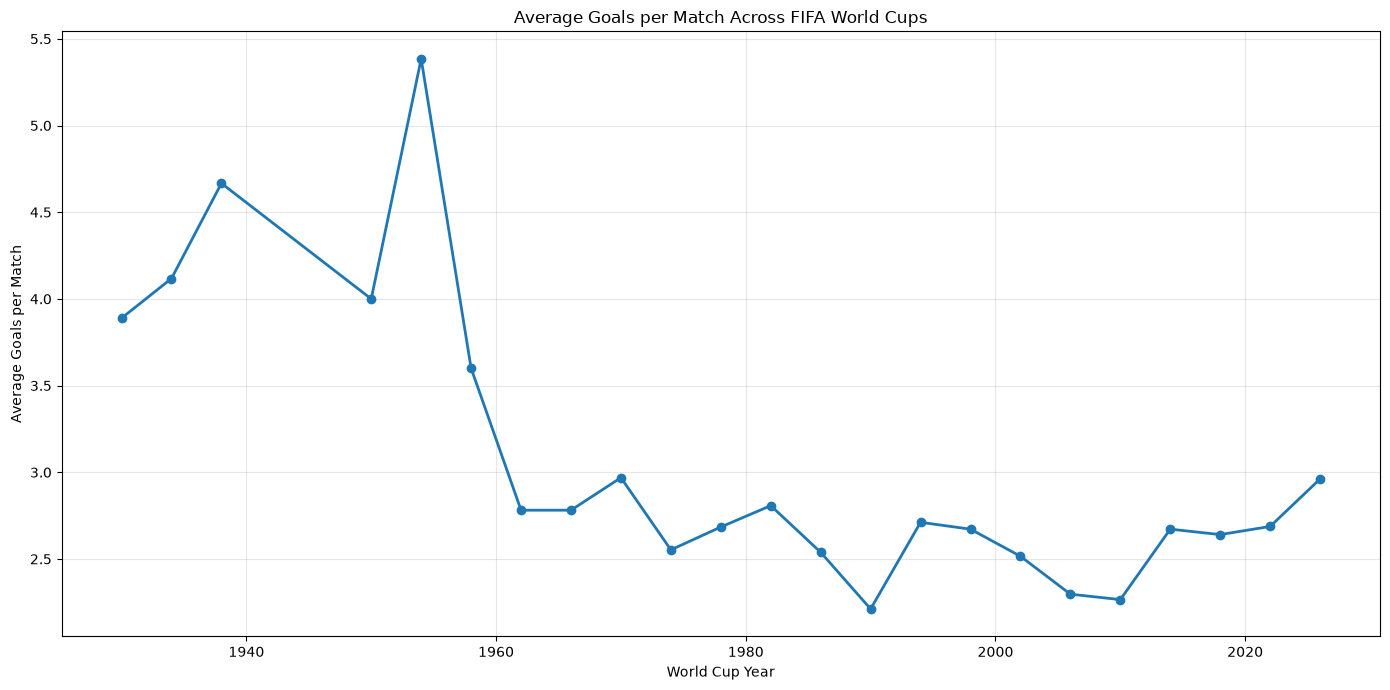

In [85]:
# =========================================================
# Q17 — Line Chart
# =========================================================

plt.figure(figsize=(14, 7))

plt.plot(
    df_q17["TournamentYear"],
    df_q17["AvgGoalsPerMatch"],
    marker="o",
    linewidth=2
)

plt.xlabel("World Cup Year")
plt.ylabel("Average Goals per Match")
plt.title("Average Goals per Match Across FIFA World Cups")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
# =========================================================
# Q17 — Basic EDA
# =========================================================

print("Highest average goals per match:",
      round(df_q17["AvgGoalsPerMatch"].max(), 4))

print("Lowest average goals per match:",
      round(df_q17["AvgGoalsPerMatch"].min(), 4))

print("Overall mean across tournaments:",
      round(df_q17["AvgGoalsPerMatch"].mean(), 4))

print("\nTop 5 tournaments by average goals per match:")

display(
    df_q17[
        [
            "TournamentYear",
            "TournamentName",
            "TotalMatches",
            "TotalGoals",
            "AvgGoalsPerMatch"
        ]
    ]
    .sort_values(
        "AvgGoalsPerMatch",
        ascending=False
    )
    .head(5)
)

Highest average goals per match: 5.3846
Lowest average goals per match: 2.2115
Overall mean across tournaments: 3.0612

Top 5 tournaments by average goals per match:


,TournamentYear,TournamentName,TotalMatches,TotalGoals,AvgGoalsPerMatch
4,1954,1954 FIFA Men's World Cup,26,140,5.3846
2,1938,1938 FIFA Men's World Cup,18,84,4.6667
1,1934,1934 FIFA Men's World Cup,17,70,4.1176
3,1950,1950 FIFA Men's World Cup,22,88,4.0000
0,1930,1930 FIFA Men's World Cup,18,70,3.8889


In [87]:
# =========================================================
# Q22 — Possession vs Match Result
# =========================================================

q22_query = """
SELECT
    ta.Result,
    tms.ValueNumeric AS PossessionPct
FROM dbo.Team_Match_Stats AS tms
INNER JOIN dbo.Team_Appearances AS ta
        ON tms.TeamAppearanceID = ta.TeamAppearanceID
INNER JOIN dbo.Matches AS m
        ON ta.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND tms.StatGroup = 'key_stats'
  AND tms.Metric = 'Possession'
  AND tms.ValueNumeric IS NOT NULL
  AND ta.Result IN ('win', 'draw', 'lose');
"""

df_q22 = run_query(q22_query)

print("Q22 — Possession vs Match Result")
print("Shape:", df_q22.shape)

display(df_q22.head(20))

Q22 — Possession vs Match Result
Shape: (208, 2)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,Result,PossessionPct
0,lose,36.1
1,win,57.1
2,lose,34.2
3,win,55.8
4,draw,52.8
5,draw,29.9
6,win,59.5
7,lose,28.7
8,lose,51.6
9,win,40.5


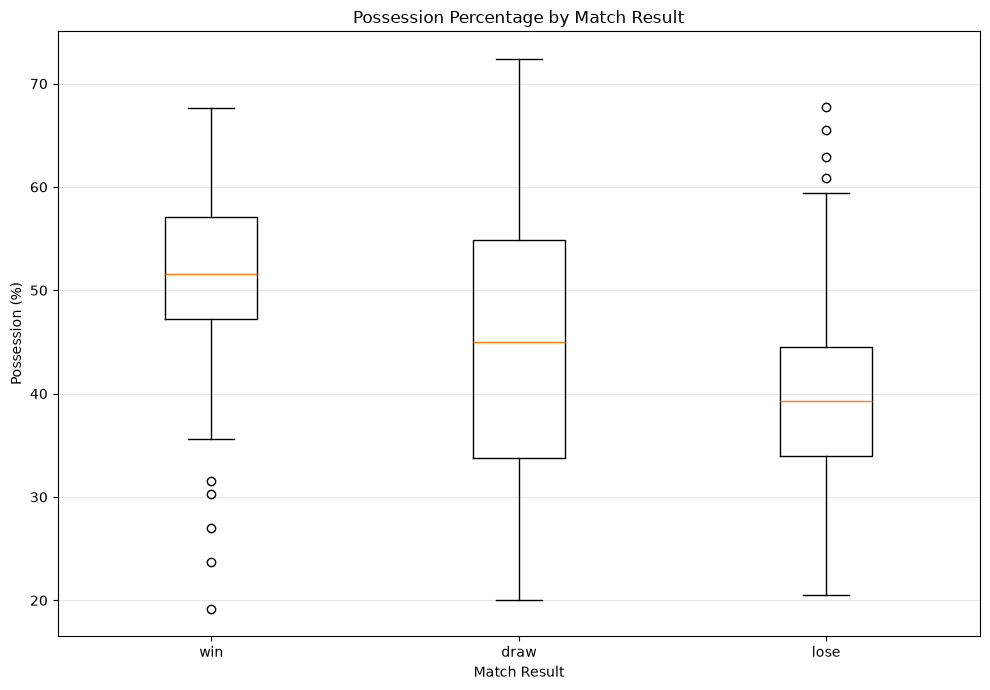

In [88]:
# =========================================================
# Q22 — Box Plot
# =========================================================

plot_order = ["win", "draw", "lose"]

plot_data = [
    df_q22.loc[
        df_q22["Result"] == result,
        "PossessionPct"
    ].dropna()
    for result in plot_order
]

plt.figure(figsize=(10, 7))

plt.boxplot(
    plot_data,
    tick_labels=plot_order
)

plt.xlabel("Match Result")
plt.ylabel("Possession (%)")
plt.title("Possession Percentage by Match Result")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
# =========================================================
# Q22 — Basic EDA
# =========================================================

print("Possession statistics by result:")

q22_summary = (
    df_q22
    .groupby("Result")["PossessionPct"]
    .agg(
        Count="count",
        Mean="mean",
        Minimum="min",
        Maximum="max"
    )
    .reindex(["win", "draw", "lose"])
)

display(q22_summary)

print(
    "Overall average possession:",
    round(df_q22["PossessionPct"].mean(), 2),
    "%"
)

Possession statistics by result:


,Count,Mean,Minimum,Maximum
Result,,,,
win,84,50.754762,19.2,67.6
draw,40,44.997500,20.0,72.4
lose,84,40.609524,20.5,67.7


Overall average possession: 45.55 %


In [90]:
# =========================================================
# Q23 — xG vs Actual Goals by Match Result
# =========================================================

q23_query = """
SELECT
    ta.Result,
    tms.ValueNumeric AS ExpectedGoals,
    CASE
        WHEN m.HomeTeamID = ta.TeamID
            THEN m.HomeScore
        ELSE m.AwayScore
    END AS ActualGoals
FROM dbo.Team_Match_Stats AS tms
INNER JOIN dbo.Team_Appearances AS ta
        ON tms.TeamAppearanceID = ta.TeamAppearanceID
INNER JOIN dbo.Matches AS m
        ON ta.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND t.TournamentYear = 2026
  AND tms.StatGroup = 'key_stats'
  AND tms.Metric = 'xG (Expected Goals)'
  AND tms.ValueNumeric IS NOT NULL
  AND m.HomeScore IS NOT NULL
  AND m.AwayScore IS NOT NULL
  AND ta.Result IN ('win', 'draw', 'lose');
"""

df_q23 = run_query(q23_query)

print("Q23 — xG vs Actual Goals by Match Result")
print("Shape:", df_q23.shape)

display(df_q23.head(20))

Q23 — xG vs Actual Goals by Match Result
Shape: (208, 3)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,Result,ExpectedGoals,ActualGoals
0,win,1.78,2
1,lose,0.10,0
2,win,1.77,2
3,lose,0.64,1
4,draw,1.49,1
5,draw,0.76,1
6,win,1.88,4
7,lose,0.60,1
8,lose,0.70,0
9,win,0.91,1


In [91]:
# =========================================================
# Q23 — Basic EDA
# =========================================================

print("xG and Actual Goals statistics by result:")

q23_summary = (
    df_q23
    .groupby("Result")
    .agg(
        Count=("ExpectedGoals", "count"),
        AverageXG=("ExpectedGoals", "mean"),
        MedianXG=("ExpectedGoals", "median"),
        AverageActualGoals=("ActualGoals", "mean"),
        MedianActualGoals=("ActualGoals", "median")
    )
    .reindex(["win", "draw", "lose"])
)

q23_summary["XGMinusActual"] = (
    q23_summary["AverageXG"]
    - q23_summary["AverageActualGoals"]
)

display(q23_summary)

print(
    "Overall average xG:",
    round(df_q23["ExpectedGoals"].mean(), 3)
)

print(
    "Overall average actual goals:",
    round(df_q23["ActualGoals"].mean(), 3)
)

xG and Actual Goals statistics by result:


,Count,AverageXG,MedianXG,AverageActualGoals,MedianActualGoals,XGMinusActual
Result,,,,,,
win,84,1.846667,1.825,2.583333,2.0,-0.736667
draw,40,1.159750,1.060,0.900000,1.0,0.259750
lose,84,0.761667,0.675,0.654762,1.0,0.106905


Overall average xG: 1.276
Overall average actual goals: 1.481


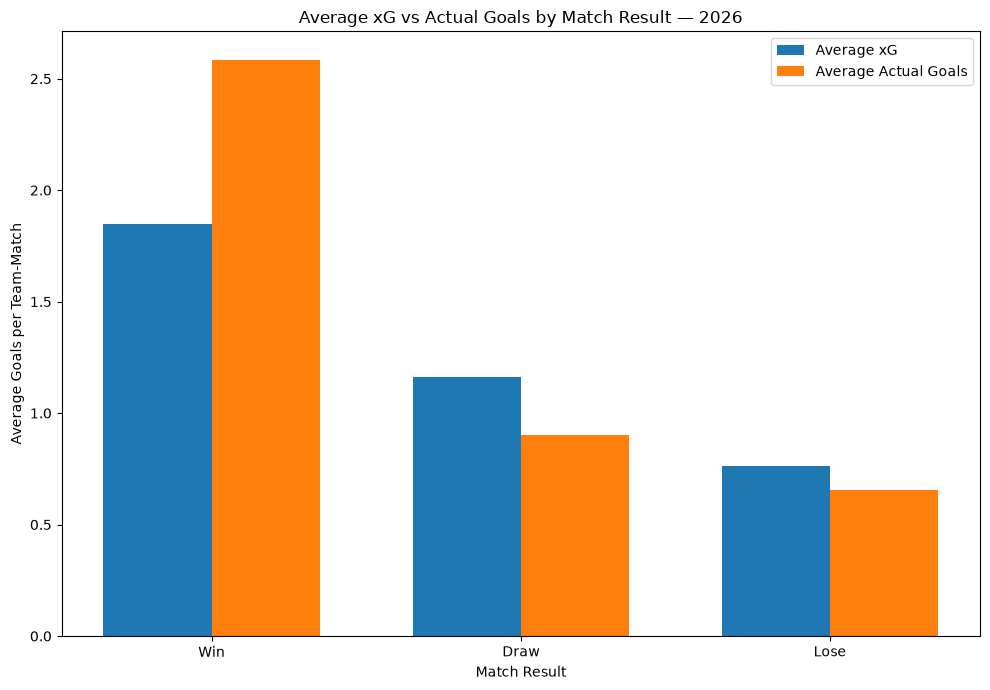

In [92]:
# =========================================================
# Q23 — Grouped Bar Chart
# =========================================================

plot_order = ["win", "draw", "lose"]

plot_summary = q23_summary.loc[
    plot_order,
    ["AverageXG", "AverageActualGoals"]
]

x = np.arange(len(plot_summary))
width = 0.35

plt.figure(figsize=(10, 7))

plt.bar(
    x - width / 2,
    plot_summary["AverageXG"],
    width,
    label="Average xG"
)

plt.bar(
    x + width / 2,
    plot_summary["AverageActualGoals"],
    width,
    label="Average Actual Goals"
)

plt.xticks(
    x,
    ["Win", "Draw", "Lose"]
)

plt.xlabel("Match Result")
plt.ylabel("Average Goals per Team-Match")
plt.title("Average xG vs Actual Goals by Match Result — 2026")
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
# =========================================================
# Q24 — Pass Completion vs Match Result
# =========================================================

q24_query = """
SELECT
    ta.Result,
    tms.ValueNumeric AS PassCompletionPct
FROM dbo.Team_Match_Stats AS tms
INNER JOIN dbo.Team_Appearances AS ta
        ON tms.TeamAppearanceID = ta.TeamAppearanceID
INNER JOIN dbo.Matches AS m
        ON ta.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS t
        ON m.TournamentID = t.TournamentID
WHERE t.Gender = 'Men'
  AND t.TournamentYear = 2026
  AND tms.StatGroup = 'key_stats'
  AND tms.Metric = 'Pass Completion %'
  AND tms.ValueNumeric IS NOT NULL
  AND ta.Result IN ('win', 'draw', 'lose');
"""

df_q24 = run_query(q24_query)

print("Q24 — Pass Completion vs Match Result")
print("Shape:", df_q24.shape)

display(df_q24.head(20))

Q24 — Pass Completion vs Match Result
Shape: (208, 2)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,Result,PassCompletionPct
0,win,90.0
1,lose,83.0
2,win,89.0
3,lose,74.0
4,draw,77.0
5,draw,67.0
6,win,86.0
7,lose,74.0
8,lose,88.0
9,win,82.0


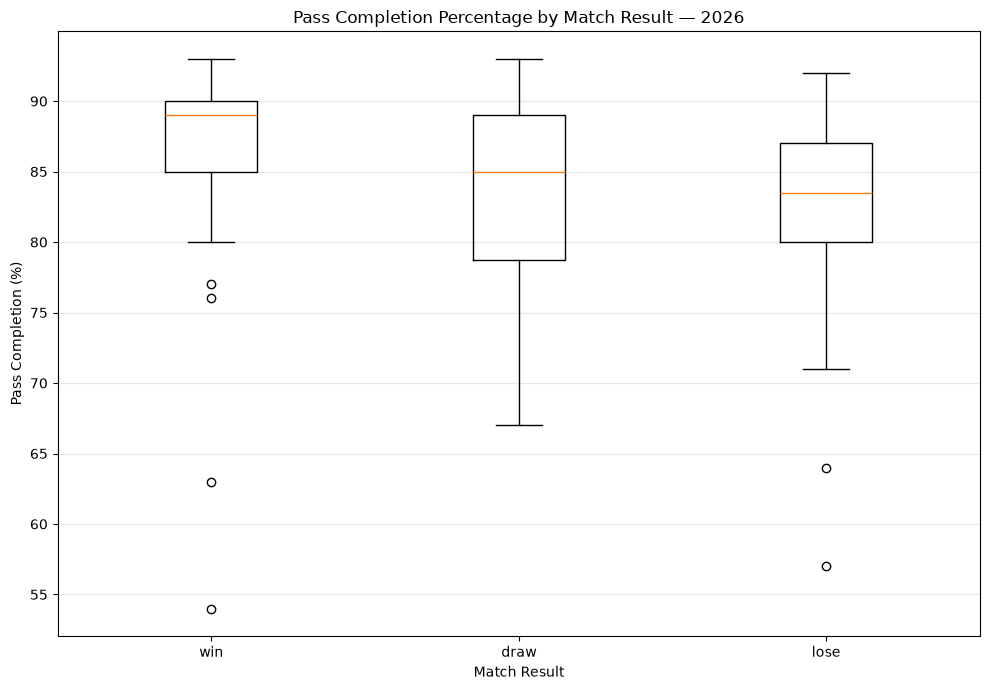

In [94]:
# =========================================================
# Q24 — Box Plot
# =========================================================

plot_order = ["win", "draw", "lose"]

plot_data = [
    df_q24.loc[
        df_q24["Result"] == result,
        "PassCompletionPct"
    ].dropna()
    for result in plot_order
]

plt.figure(figsize=(10, 7))

plt.boxplot(
    plot_data,
    tick_labels=plot_order
)

plt.xlabel("Match Result")
plt.ylabel("Pass Completion (%)")
plt.title("Pass Completion Percentage by Match Result — 2026")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
# =========================================================
# Q24 — Basic EDA
# =========================================================

print("Pass completion statistics by result:")

q24_summary = (
    df_q24
    .groupby("Result")["PassCompletionPct"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reindex(["win", "draw", "lose"])
)

display(q24_summary)

print(
    "Overall average pass completion:",
    round(df_q24["PassCompletionPct"].mean(), 2),
    "%"
)

Pass completion statistics by result:


,Count,Mean,Median,Minimum,Maximum
Result,,,,,
win,84,87.142857,89.0,54.0,93.0
draw,40,83.475000,85.0,67.0,93.0
lose,84,82.702381,83.5,57.0,92.0


Overall average pass completion: 84.64 %


In [96]:
# =========================================================
# Q26 — Men's World Cup Team Win Rate
# =========================================================

q26_query = """
SELECT
    t.TeamID,
    t.TeamName,
    COUNT(*) AS TotalMatches,
    SUM(CASE WHEN ta.Result = 'win' THEN 1 ELSE 0 END) AS Wins,
    SUM(CASE WHEN ta.Result = 'draw' THEN 1 ELSE 0 END) AS Draws,
    SUM(CASE WHEN ta.Result = 'lose' THEN 1 ELSE 0 END) AS Losses,
    CAST(
        100.0 *
        SUM(CASE WHEN ta.Result = 'win' THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0)
        AS DECIMAL(10,2)
    ) AS WinRatePercentage
FROM dbo.Teams AS t
INNER JOIN dbo.Team_Appearances AS ta
        ON t.TeamID = ta.TeamID
INNER JOIN dbo.Matches AS m
        ON ta.MatchID = m.MatchID
INNER JOIN dbo.Tournaments AS tr
        ON m.TournamentID = tr.TournamentID
WHERE tr.Gender = 'Men'
GROUP BY
    t.TeamID,
    t.TeamName
HAVING COUNT(*) >= 10
ORDER BY
    WinRatePercentage DESC,
    t.TeamName;
"""

df_q26 = run_query(q26_query)

print("Q26 — Men's World Cup Team Win Rate")
print("Shape:", df_q26.shape)

display(df_q26.head(20))

Q26 — Men's World Cup Team Win Rate
Shape: (55, 7)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,TeamID,TeamName,TotalMatches,Wins,Draws,Losses,WinRatePercentage
0,T-09,Brazil,119,82,15,22,68.91
1,T-31,Germany,54,35,6,13,64.81
2,T-86,West Germany,62,39,11,12,62.90
3,T-03,Argentina,96,60,10,26,62.50
4,T-30,France,81,47,9,25,58.02
5,T-48,Netherlands,59,33,11,15,55.93
6,T-18,Croatia,34,19,4,11,55.88
7,T-41,Italy,83,46,17,20,55.42
8,T-73,Spain,75,39,13,23,52.00
9,T-58,Portugal,40,20,7,13,50.00


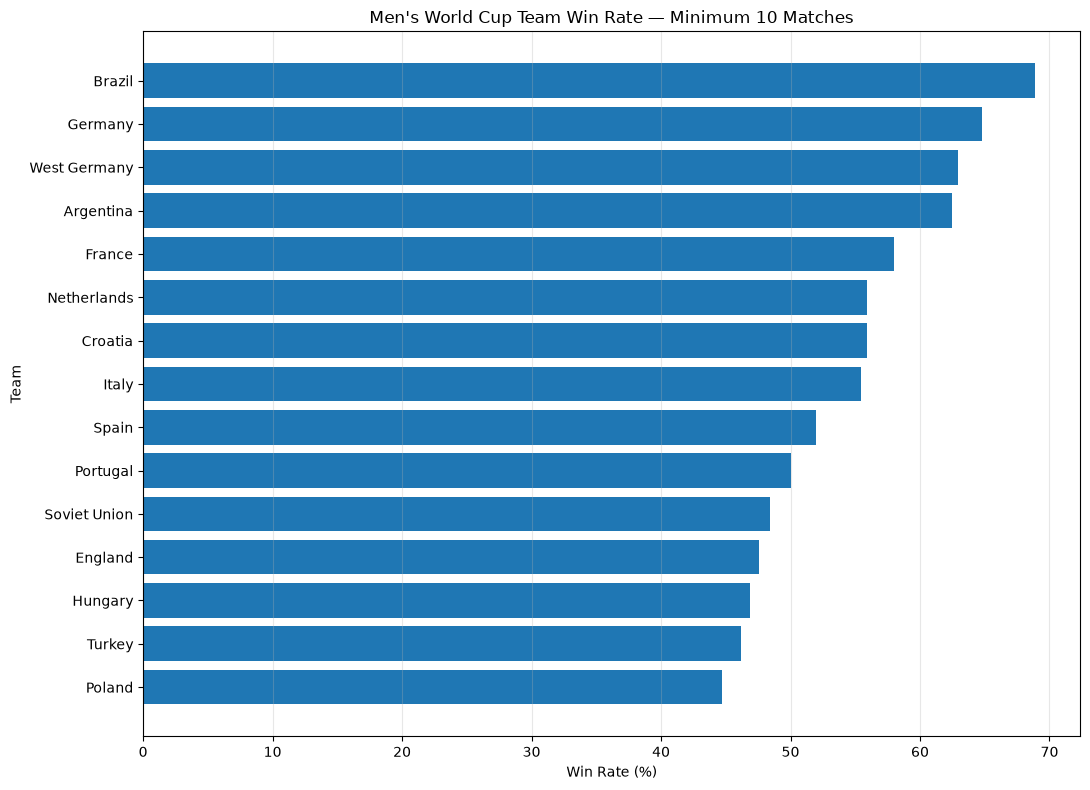

In [97]:
# =========================================================
# Q26 — Horizontal Bar Chart
# =========================================================

plot_df = (
    df_q26
    .nlargest(15, "WinRatePercentage")
    .sort_values("WinRatePercentage", ascending=True)
)

plt.figure(figsize=(11, 8))

plt.barh(
    plot_df["TeamName"],
    plot_df["WinRatePercentage"]
)

plt.xlabel("Win Rate (%)")
plt.ylabel("Team")
plt.title("Men's World Cup Team Win Rate — Minimum 10 Matches")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
# =========================================================
# Q26 — Basic EDA
# =========================================================

print("Team win-rate summary:")

q26_summary = df_q26[
    [
        "TeamName",
        "TotalMatches",
        "Wins",
        "Draws",
        "Losses",
        "WinRatePercentage"
    ]
].copy()

display(q26_summary.head(15))

print(
    "Number of teams meeting the 10-match threshold:",
    len(df_q26)
)

print(
    "Maximum win rate:",
    round(df_q26["WinRatePercentage"].max(), 2),
    "%"
)

print(
    "Minimum win rate:",
    round(df_q26["WinRatePercentage"].min(), 2),
    "%"
)

print(
    "Mean win rate among included teams:",
    round(df_q26["WinRatePercentage"].mean(), 2),
    "%"
)

Team win-rate summary:


,TeamName,TotalMatches,Wins,Draws,Losses,WinRatePercentage
0,Brazil,119,82,15,22,68.91
1,Germany,54,35,6,13,64.81
2,West Germany,62,39,11,12,62.90
3,Argentina,96,60,10,26,62.50
4,France,81,47,9,25,58.02
5,Netherlands,59,33,11,15,55.93
6,Croatia,34,19,4,11,55.88
7,Italy,83,46,17,20,55.42
8,Spain,75,39,13,23,52.00
9,Portugal,40,20,7,13,50.00


Number of teams meeting the 10-match threshold: 55
Maximum win rate: 68.91 %
Minimum win rate: 14.29 %
Mean win rate among included teams: 36.6 %


In [99]:
# =========================================================
# Q29 — Average xG vs Actual Goals by Team — 2026
# =========================================================

q29_query = """
WITH DetailedTeamMatchXG AS
(
    SELECT DISTINCT
        s.MatchID,
        s.TeamID,
        s.ValueNumeric AS MatchXG,
        CASE
            WHEN m.HomeTeamID = s.TeamID
                THEN m.HomeScore
            ELSE m.AwayScore
        END AS MatchActualGoals
    FROM dbo.Team_Match_Stats AS s
    INNER JOIN dbo.Matches AS m
            ON s.MatchID = m.MatchID
    INNER JOIN dbo.Tournaments AS t
            ON m.TournamentID = t.TournamentID
    WHERE s.StatGroup = 'key_stats'
      AND s.Metric = 'xG (Expected Goals)'
      AND s.TeamID IS NOT NULL
      AND s.ValueNumeric IS NOT NULL
      AND t.Gender = 'Men'
      AND t.TournamentYear = 2026
      AND m.HomeScore IS NOT NULL
      AND m.AwayScore IS NOT NULL
)
SELECT
    tm.TeamID,
    tm.TeamName,
    COUNT(*) AS MatchesWithXG,
    AVG(dtm.MatchXG) AS AverageXGPerMatch,
    AVG(
        CAST(dtm.MatchActualGoals AS DECIMAL(10,2))
    ) AS AverageActualGoalsPerMatch,
    AVG(
        dtm.MatchXG
        - CAST(dtm.MatchActualGoals AS DECIMAL(10,2))
    ) AS AverageXGMinusActualGoals
FROM DetailedTeamMatchXG AS dtm
INNER JOIN dbo.Teams AS tm
        ON dtm.TeamID = tm.TeamID
GROUP BY
    tm.TeamID,
    tm.TeamName
ORDER BY
    AverageXGMinusActualGoals DESC,
    tm.TeamName;
"""

df_q29 = run_query(q29_query)

print("Q29 — Average xG vs Actual Goals by Team")
print("Shape:", df_q29.shape)

display(df_q29)

Q29 — Average xG vs Actual Goals by Team
Shape: (48, 6)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,TeamID,TeamName,MatchesWithXG,AverageXGPerMatch,AverageActualGoalsPerMatch,AverageXGMinusActualGoals
0,T-25,Ecuador,4,1.470000,0.500000,0.970000
1,T-80,Turkey,3,1.833333,1.000000,0.833333
2,T-54,Panama,3,0.726666,0.000000,0.726666
3,T-38,Iran,3,1.523333,1.000000,0.523333
4,T-16,Colombia,5,1.470000,1.000000,0.470000
5,T-71,South Korea,3,1.126666,0.666666,0.460000
6,T-64,Scotland,3,0.780000,0.333333,0.446666
7,T-73,Spain,8,2.185000,1.750000,0.435000
8,T-39,Iraq,3,0.703333,0.333333,0.370000
9,T-84,Uruguay,3,1.316666,1.000000,0.316666


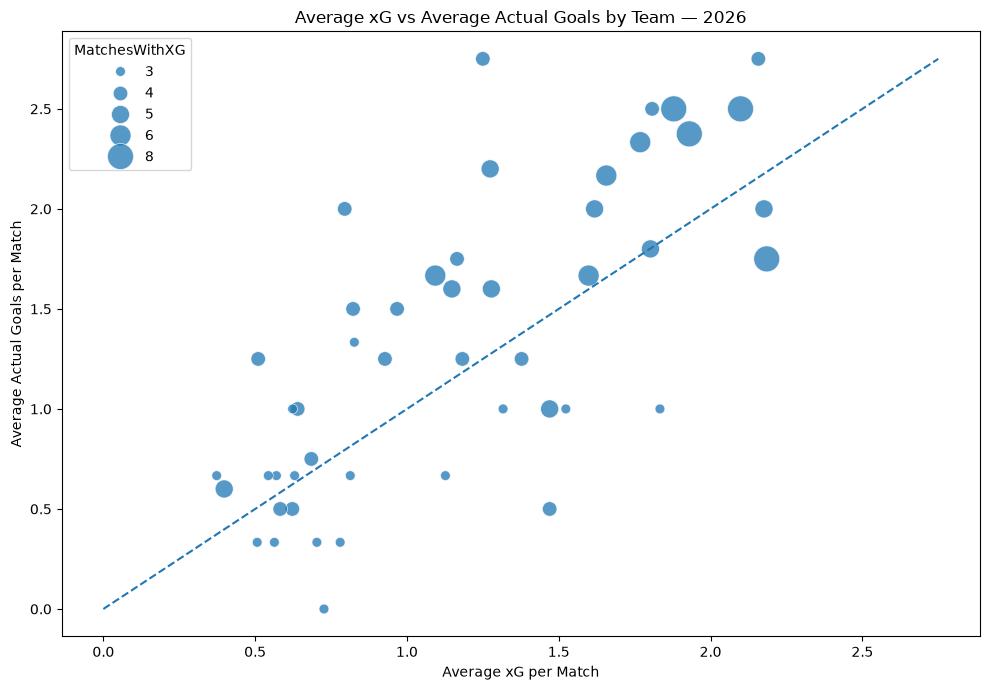

In [100]:
# =========================================================
# Q29 — Scatter Plot
# =========================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_q29,
    x="AverageXGPerMatch",
    y="AverageActualGoalsPerMatch",
    size="MatchesWithXG",
    sizes=(50, 350),
    alpha=0.75
)

max_value = max(
    df_q29["AverageXGPerMatch"].max(),
    df_q29["AverageActualGoalsPerMatch"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Average xG per Match")
plt.ylabel("Average Actual Goals per Match")
plt.title("Average xG vs Average Actual Goals by Team — 2026")

plt.tight_layout()
plt.show()

In [101]:
# =========================================================
# Q29 — Statistical Analysis
# =========================================================

print("Q29 descriptive statistics:")

display(
    df_q29[
        [
            "MatchesWithXG",
            "AverageXGPerMatch",
            "AverageActualGoalsPerMatch",
            "AverageXGMinusActualGoals"
        ]
    ].describe()
)

pearson_corr = (
    df_q29[
        [
            "AverageXGPerMatch",
            "AverageActualGoalsPerMatch"
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

spearman_corr = (
    df_q29[
        [
            "AverageXGPerMatch",
            "AverageActualGoalsPerMatch"
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

print("\nLargest positive xG - actual gaps:")
display(
    df_q29.nlargest(
        5,
        "AverageXGMinusActualGoals"
    )[
        [
            "TeamName",
            "MatchesWithXG",
            "AverageXGPerMatch",
            "AverageActualGoalsPerMatch",
            "AverageXGMinusActualGoals"
        ]
    ]
)

print("\nLargest negative xG - actual gaps:")
display(
    df_q29.nsmallest(
        5,
        "AverageXGMinusActualGoals"
    )[
        [
            "TeamName",
            "MatchesWithXG",
            "AverageXGPerMatch",
            "AverageActualGoalsPerMatch",
            "AverageXGMinusActualGoals"
        ]
    ]
)

Q29 descriptive statistics:


,MatchesWithXG,AverageXGPerMatch,AverageActualGoalsPerMatch,AverageXGMinusActualGoals
count,48.000000,48.000000,48.000000,48.000000
mean,4.333333,1.162410,1.321354,-0.158944
std,1.448893,0.540684,0.744334,0.513320
min,3.000000,0.373333,0.000000,-1.500000
25%,3.000000,0.673750,0.666666,-0.515625
50%,4.000000,1.137333,1.250000,-0.162666
75%,5.000000,1.603250,1.850000,0.174000
max,8.000000,2.185000,2.750000,0.970000


Pearson correlation: 0.7242
Spearman correlation: 0.7277

Largest positive xG - actual gaps:


,TeamName,MatchesWithXG,AverageXGPerMatch,AverageActualGoalsPerMatch,AverageXGMinusActualGoals
0,Ecuador,4,1.470000,0.5,0.970000
1,Turkey,3,1.833333,1.0,0.833333
2,Panama,3,0.726666,0.0,0.726666
3,Iran,3,1.523333,1.0,0.523333
4,Colombia,5,1.470000,1.0,0.470000



Largest negative xG - actual gaps:


,TeamName,MatchesWithXG,AverageXGPerMatch,AverageActualGoalsPerMatch,AverageXGMinusActualGoals
47,Netherlands,4,1.2500,2.75,-1.5000
46,Japan,4,0.7950,2.00,-1.2050
45,United States,5,1.2740,2.20,-0.9260
44,Bosnia and Herzegovina,4,0.5100,1.25,-0.7400
43,Senegal,4,1.8075,2.50,-0.6925


In [102]:
# =========================================================
# Q31 — FIFA Pre-Tournament Rank vs 2026 Win Rate
# =========================================================

q31_query = """
WITH TeamTournamentPerformance AS
(
    SELECT
        ta.TeamID,
        COUNT(*) AS TotalMatches,
        SUM(
            CASE
                WHEN ta.Result = 'win' THEN 1
                ELSE 0
            END
        ) AS Wins,
        CAST(
            100.0 *
            SUM(
                CASE
                    WHEN ta.Result = 'win' THEN 1
                    ELSE 0
                END
            )
            / NULLIF(COUNT(*), 0)
            AS DECIMAL(10,2)
        ) AS WinRate
    FROM dbo.Tournaments AS t
    INNER JOIN dbo.Matches AS m
            ON t.TournamentID = m.TournamentID
    INNER JOIN dbo.Team_Appearances AS ta
            ON m.MatchID = ta.MatchID
    WHERE t.Gender = 'Men'
      AND t.TournamentYear = 2026
    GROUP BY
        ta.TeamID
)
SELECT
    tm.TeamID,
    tm.TeamName,
    fr.RankingDate,
    fr.RankPosition AS FIFA_PreTournamentRank,
    fr.Points AS FIFA_Points,
    tp.TotalMatches,
    tp.Wins,
    tp.WinRate
FROM TeamTournamentPerformance AS tp
INNER JOIN dbo.FIFA_Rankings AS fr
        ON fr.WorldCupTeamID = tp.TeamID
       AND fr.RankingDate = '2026-06-11'
INNER JOIN dbo.Teams AS tm
        ON tm.TeamID = tp.TeamID
ORDER BY
    fr.RankPosition,
    tm.TeamName;
"""

df_q31 = run_query(q31_query)

print("Q31 — FIFA Pre-Tournament Rank vs 2026 Win Rate")
print("Shape:", df_q31.shape)

display(df_q31)

Q31 — FIFA Pre-Tournament Rank vs 2026 Win Rate
Shape: (48, 8)


C:\Users\Electronica Care\AppData\Local\Temp\ipykernel_13484\1632291425.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, connection)


,TeamID,TeamName,RankingDate,FIFA_PreTournamentRank,FIFA_Points,TotalMatches,Wins,WinRate
0,T-03,Argentina,2026-06-11,1,1877.27,8,7,87.50
1,T-73,Spain,2026-06-11,2,1874.71,8,7,87.50
2,T-30,France,2026-06-11,3,1870.70,8,6,75.00
3,T-28,England,2026-06-11,4,1828.02,8,6,75.00
4,T-58,Portugal,2026-06-11,5,1767.85,5,2,40.00
5,T-09,Brazil,2026-06-11,6,1765.86,5,3,60.00
6,T-47,Morocco,2026-06-11,7,1755.10,6,4,66.67
7,T-48,Netherlands,2026-06-11,8,1753.57,4,2,50.00
8,T-06,Belgium,2026-06-11,9,1742.24,6,3,50.00
9,T-31,Germany,2026-06-11,10,1735.77,4,2,50.00


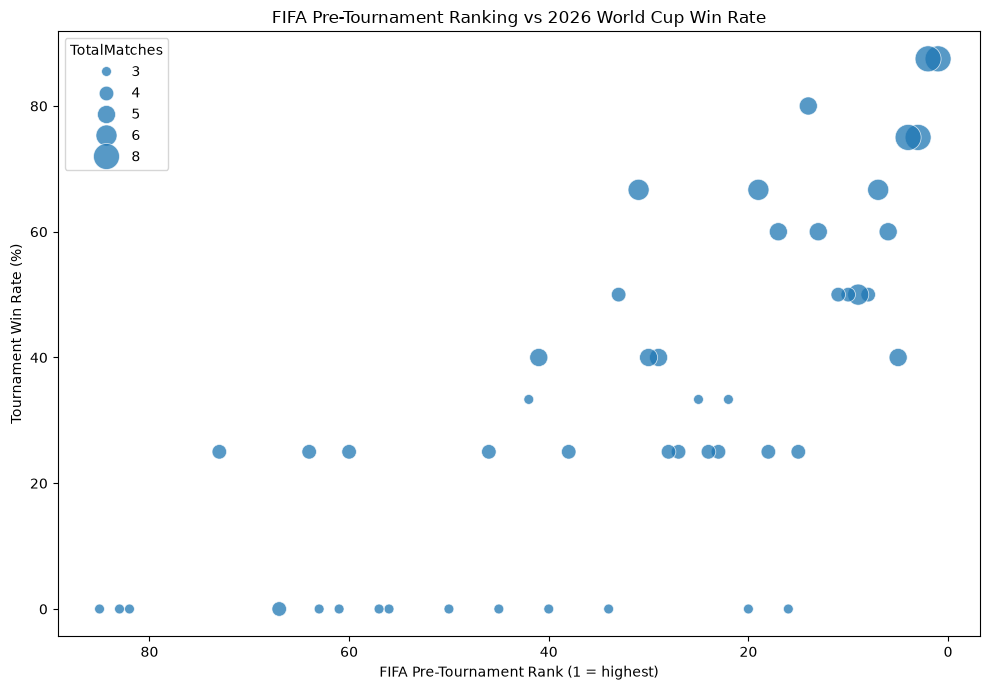

In [103]:
# =========================================================
# Q31 — Scatter Plot
# =========================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_q31,
    x="FIFA_PreTournamentRank",
    y="WinRate",
    size="TotalMatches",
    sizes=(50, 350),
    alpha=0.75
)

plt.gca().invert_xaxis()

plt.xlabel("FIFA Pre-Tournament Rank (1 = highest)")
plt.ylabel("Tournament Win Rate (%)")
plt.title("FIFA Pre-Tournament Ranking vs 2026 World Cup Win Rate")

plt.tight_layout()
plt.show()

In [104]:
# =========================================================
# Q31 — Statistical Analysis
# =========================================================

from scipy.stats import spearmanr

print("Q31 descriptive statistics:")

display(
    df_q31[
        [
            "FIFA_PreTournamentRank",
            "FIFA_Points",
            "TotalMatches",
            "Wins",
            "WinRate"
        ]
    ].describe()
)

spearman_rho, spearman_p = spearmanr(
    df_q31["FIFA_PreTournamentRank"],
    df_q31["WinRate"]
)

print(f"Q31 observations: {len(df_q31)}")
print(f"Spearman rho: {spearman_rho:.4f}")
print(f"p-value: {spearman_p:.10g}")

print(
    "\nCorrelation direction note:"
)
print(
    "Lower FIFA rank number represents a better ranking position, "
    "so the sign of rho should be interpreted with that ordering in mind."
)

Q31 descriptive statistics:


,FIFA_PreTournamentRank,FIFA_Points,TotalMatches,Wins,WinRate
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,32.437500,1580.695625,4.333333,1.750000,32.708333
std,23.723501,157.241424,1.448893,1.896245,27.231377
min,1.000000,1275.580000,3.000000,0.000000,0.000000
25%,13.750000,1470.505000,3.000000,0.000000,0.000000
50%,27.500000,1575.185000,4.000000,1.000000,25.000000
75%,47.000000,1690.197500,5.000000,2.250000,50.000000
max,85.000000,1877.270000,8.000000,7.000000,87.500000


Q31 observations: 48
Spearman rho: -0.7531
p-value: 6.600889727e-10

Correlation direction note:
Lower FIFA rank number represents a better ranking position, so the sign of rho should be interpreted with that ordering in mind.
